# Stop/Target Short Strangle — BirdsEye stress test

Runs `StopTargetShortStrangle` on SPY 0-DTE train days.  
**Purpose:** framework stress test — exercises SLTP brackets, transition priority, execution slicer, cost model, and re-entry lifecycle.  

FSM:
```
WAIT  --[entry_window]----> SHORT
SHORT --[stop_hit]--------> FLATTEN    (priority 1 — loss >= stop_pct * credit)
SHORT --[target_hit]------> FLATTEN    (priority 2 — gain >= tp_pct  * credit)
SHORT --[eod_squareoff]---> FLATTEN    (priority 3 — near close)
SHORT --[time_stop]-------> FLATTEN    (priority 4 — max hold elapsed)
FLATTEN --[always]---------> WAIT
```

In [ ]:
from engine import BirdsEye
from strategies.stop_target_short_strangle import StopTargetShortStrangle

be = BirdsEye(
    strategy_cls    = StopTargetShortStrangle,
    index           = "SPY",
    split           = "train",
    strategy_kwargs = {
        "lots"           : 20,
        "width_steps"    : 2,     # OTM legs: ATM ± 2 strikes
        "stop_pct"       : 0.5,   # stop when loss >= 0.5x credit collected
        "tp_pct"         : 0.75,   # take when gain >= 0.75x credit collected
        "decision_every" : 1800,  # attempt entry every 30 min
        "hold_max"       : 2400,  # time-stop after 40 min
        "eod_sec"        : 23100, # hard square-off ~15 min before close
    },
    # cost_kwargs   = {"txn_cost_per_lot": 0.85},
    lot_size      = 100,
    starting_cash = 1_000_000.0,
    n_workers     = 40,
    # days=["20240102", "20240104"],  # uncomment for a quick subset
)
res = be.run()

[birdseye] log -> /home/krishna/Project/BirdsEye/logs/SPY_train_20260615_145831.log


## 1. Per-day summary & aggregate stats

In [2]:
import pandas as pd
pd.set_option("display.max_rows", 60)

print("=== per-day summary ===")
display(res.summary)

print("\n=== aggregate stats ===")
for k, v in res.stats().items():
    print(f"  {k:<18}: {v}")

=== per-day summary ===


,fills,gross($),costs($),net($)
day,,,,
20240102,96,-50.0,0.0,-50.0
20240104,96,-10.0,0.0,-10.0
20240105,96,-1102.5,0.0,-1102.5
20240109,96,-20.0,0.0,-20.0
20240110,88,437.5,0.0,437.5
...,...,...,...,...
20250804,88,505.0,0.0,505.0
20250806,88,637.5,0.0,637.5
20250807,104,-1455.0,0.0,-1455.0



=== aggregate stats ===
  n_days            : 277
  total_pnl         : 47730.0
  avg_day           : 172.31
  pct_pos_days      : 0.65
  pct_neg_days      : 0.35
  avg_win           : 853.74
  avg_loss          : -1072.35
  best_day          : 4107.5
  worst_day         : -5280.0
  win_rate          : 0.65
  cagr              : 0.04
  calmar            : 2.27
  maxDD_pct         : -0.02
  churn_per_day     : 0.02
  daily_maxDD       : -19570.0
  intraday_maxDD    : -14362.5
  total_costs       : 0.0
  n_fills           : 25720


## 2. Tearsheet — daily PnL, equity curve, drawdown

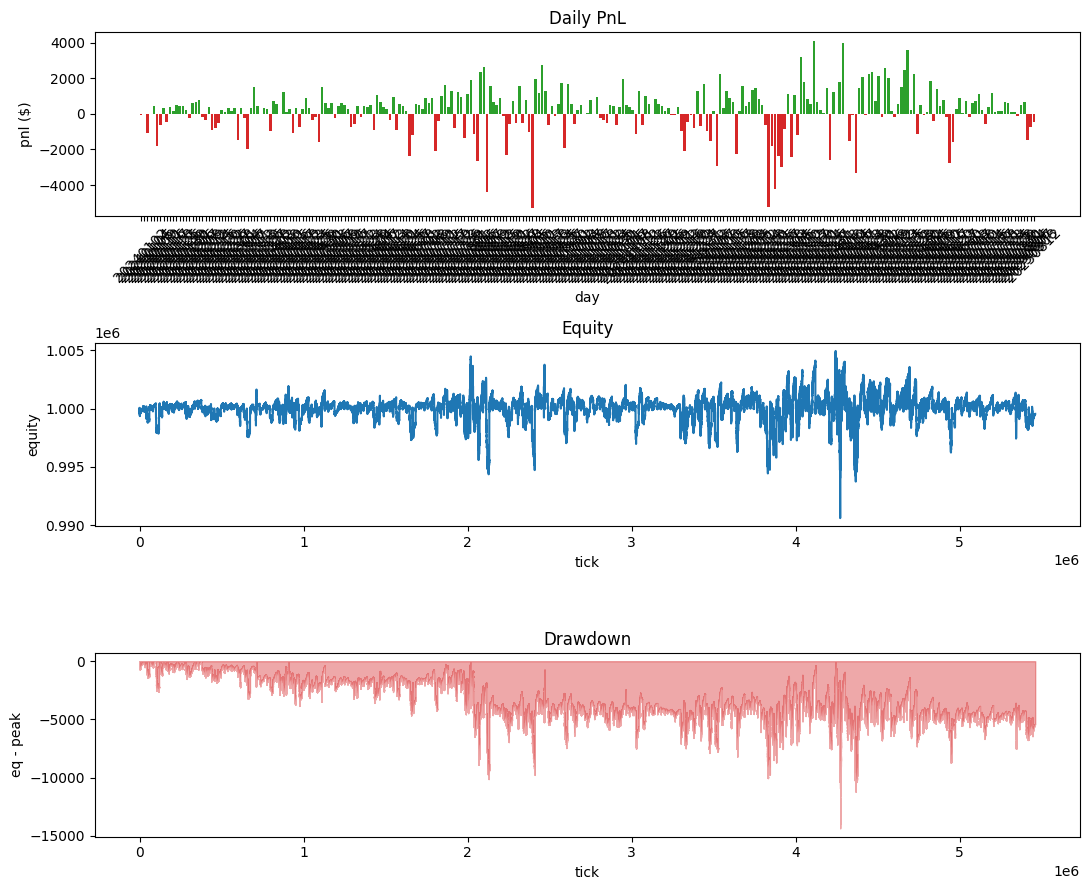

In [3]:
import matplotlib.pyplot as plt
res.tearsheet()
plt.show()

## 3. Single-day deep dive

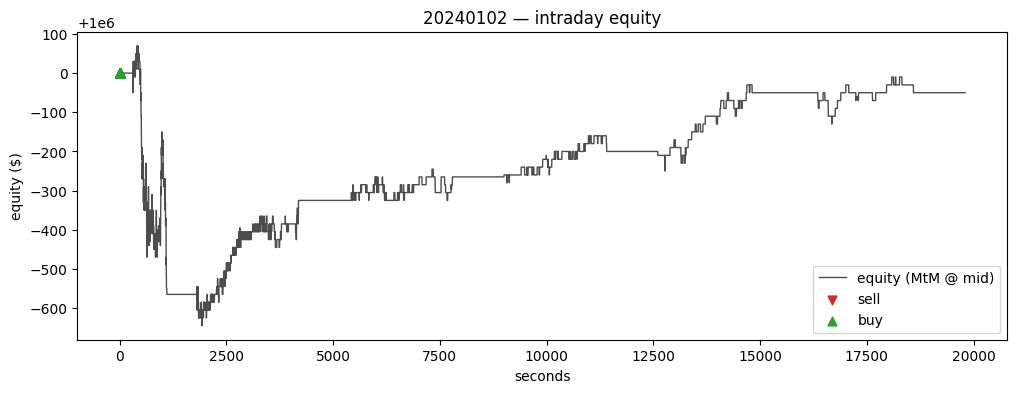

In [4]:
DAY = res.days[0]   # change to any day in res.days

res.plot_day(DAY)
plt.show()

## 4. Trade ledger — exits by signal

The key SLTP check: every trade exit is labelled by which guard fired.
- `stop_hit` — stop-loss (loss ≥ 1× credit)
- `target_hit` — take-profit (gain ≥ 0.5× credit)
- `eod_squareoff` — forced close near end of day
- `time_stop` — max hold time elapsed
- `entry_window` — the opening leg (no exit signal)

In [5]:
led = res.Tradelog()
print(f"{len(led)} total fills across {len(res.days)} days\n")

EXIT_SIGNALS = ["stop_hit", "target_hit", "eod_squareoff", "time_stop"]
exits = led[led["signal"].isin(EXIT_SIGNALS)]

print("=== exit fills by signal ===")
display(
    exits.groupby("signal")["exe_cost"]
         .agg(count="count", total_cost="sum")
         .round(2)
)

print("\n=== first 10 fills (all alpha_* columns show values at fire time) ===")
display(led.head(10))
led

25720 total fills across 277 days

=== exit fills by signal ===


,count,total_cost
signal,,
stop_hit,2064,0.0
target_hit,8,0.0
time_stop,10128,0.0



=== first 10 fills (all alpha_* columns show values at fire time) ===


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,...,signal,note,alpha_sec,alpha_spot,alpha_ce_strike,alpha_pe_strike,alpha_legs_quoted,alpha_open_pnl,alpha_entry_credit,alpha_decision_now
0,20240102,301,475.0,CE,SELL,5,0.20,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
1,20240102,301,471.0,PE,SELL,5,0.34,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
2,20240102,304,475.0,CE,SELL,5,0.20,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
3,20240102,304,471.0,PE,SELL,5,0.34,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
4,20240102,307,475.0,CE,SELL,5,0.20,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
5,20240102,307,471.0,PE,SELL,5,0.34,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
6,20240102,310,475.0,CE,SELL,5,0.20,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
7,20240102,310,471.0,PE,SELL,5,0.36,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
8,20240102,1100,475.0,CE,BUY,5,0.08,0.0,0.0,0,...,stop_hit,square off,1099,471.52,474.0,470.0,1,-550.0,1090.0,0
9,20240102,1100,471.0,PE,BUY,5,0.74,0.0,0.0,0,...,stop_hit,square off,1099,471.52,474.0,470.0,1,-550.0,1090.0,0


,day,timestamp,strike,opt_type,action,lots,fill_price,txn_cost,brokerage,spread_cost,...,signal,note,alpha_sec,alpha_spot,alpha_ce_strike,alpha_pe_strike,alpha_legs_quoted,alpha_open_pnl,alpha_entry_credit,alpha_decision_now
0,20240102,301,475.0,CE,SELL,5,0.20,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
1,20240102,301,471.0,PE,SELL,5,0.34,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
2,20240102,304,475.0,CE,SELL,5,0.20,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
3,20240102,304,471.0,PE,SELL,5,0.34,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
4,20240102,307,475.0,CE,SELL,5,0.20,0.0,0.0,0,...,entry_window,strangle 471.0/475.0,300,472.63,475.0,471.0,1,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25715,20250812,18604,640.0,PE,BUY,5,0.06,0.0,0.0,0,...,time_stop,square off,18600,642.03,644.0,640.0,1,40.0,260.0,0
25716,20250812,18607,644.0,CE,BUY,5,0.04,0.0,0.0,0,...,time_stop,square off,18600,642.03,644.0,640.0,1,40.0,260.0,0
25717,20250812,18607,640.0,PE,BUY,5,0.06,0.0,0.0,0,...,time_stop,square off,18600,642.03,644.0,640.0,1,40.0,260.0,0
25718,20250812,18610,644.0,CE,BUY,5,0.04,0.0,0.0,0,...,time_stop,square off,18600,642.03,644.0,640.0,1,40.0,260.0,0


## 5. Per-second flight recorder — state timeline & alphas

per-second log 20240102: 19681 rows
columns: ['timestamp', 'spot', 'atm', 'state', 'sec', 'ce_strike', 'pe_strike', 'legs_quoted', 'open_pnl', 'entry_credit', 'decision_now']

=== state transitions ===


,timestamp,state,sec,open_pnl,entry_credit
0,0,WAIT,NaN,NaN,NaN
301,311,SHORT,311.0,-10.0,1090.0
1090,1110,FLATTEN,1110.0,0.0,0.0
1091,1111,WAIT,1111.0,0.0,0.0
1781,1811,SHORT,1811.0,0.0,940.0
4171,4211,FLATTEN,4211.0,0.0,0.0
4172,4212,WAIT,4212.0,0.0,0.0
5361,5411,SHORT,5411.0,0.0,540.0
7751,7811,FLATTEN,7811.0,0.0,0.0
7752,7812,WAIT,7812.0,0.0,0.0



=== state occupancy (seconds) ===


state
SHORT      12739
WAIT        6936
FLATTEN        6
Name: count, dtype: int64

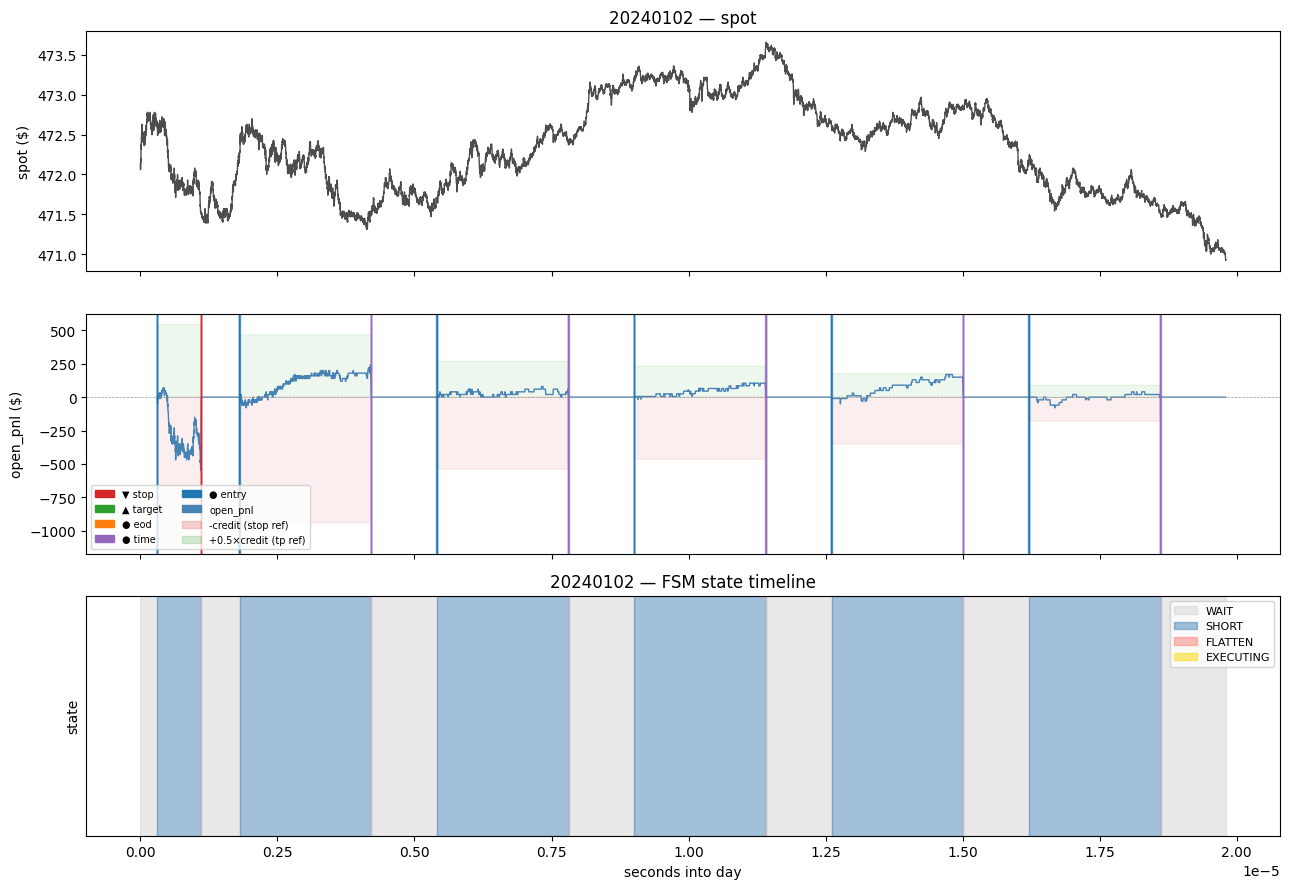

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

sl  = res.perseclog(DAY)
led = res.Tradelog()
day_led = led[led["day"] == DAY].copy()

print(f"per-second log {DAY}: {len(sl)} rows")
print(f"columns: {list(sl.columns)}\n")

# --- state transitions: rows where state changes ---
state_changes = sl[sl["state"] != sl["state"].shift()]
print("=== state transitions ===")
display(state_changes[["timestamp", "state"] + [c for c in ["sec", "open_pnl", "entry_credit"] if c in sl.columns]])

print("\n=== state occupancy (seconds) ===")
display(sl["state"].value_counts())

# --- signal events from the tradelog (deduplicated to one row per guard fire) ---
# Each signal fires once per order but produces 2 fill rows (CE + PE leg).
# Keep the first fill per (timestamp, signal) to get one marker per event.
sig_events = (day_led[day_led["signal"].isin(EXIT_SIGNALS + ["entry_window"])]
              .drop_duplicates(subset=["timestamp", "signal"]))

# map timestamps to second-index in the perseclog
ts0 = sl["timestamp"].iloc[0]
sl_sec = ((sl["timestamp"] - ts0) / 1e9).values   # relative seconds

def ts_to_sec(ts):
    return (ts - ts0) / 1e9

# --- plot: open_pnl with signal markers ---
COLORS = {
    "stop_hit":      ("tab:red",    "▼ stop"),
    "target_hit":    ("tab:green",  "▲ target"),
    "eod_squareoff": ("tab:orange", "● eod"),
    "time_stop":     ("tab:purple", "● time"),
    "entry_window":  ("tab:blue",   "● entry"),
}

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# panel 1: spot
axes[0].plot(sl_sec, sl["spot"], lw=1, color="0.3")
axes[0].set_ylabel("spot ($)")
axes[0].set_title(f"{DAY} — spot")

# panel 2: open_pnl with stop/target reference lines and signal markers
if "open_pnl" in sl.columns:
    axes[1].plot(sl_sec, sl["open_pnl"], lw=1, color="steelblue", label="open_pnl")
    axes[1].axhline(0, color="0.6", lw=0.5, ls="--")

    # credit reference lines where we're in SHORT
    if "entry_credit" in sl.columns and "state" in sl.columns:
        short_mask = sl["state"] == "SHORT"
        cr = sl["entry_credit"].where(short_mask)
        axes[1].fill_between(sl_sec, -cr, 0,        alpha=0.08, color="tab:red",   label="-credit (stop ref)")
        axes[1].fill_between(sl_sec, 0,   cr * 0.5, alpha=0.08, color="tab:green", label="+0.5×credit (tp ref)")

    for _, row in sig_events.iterrows():
        sig  = row["signal"]
        col, label = COLORS.get(sig, ("grey", sig))
        x = ts_to_sec(row["timestamp"])
        axes[1].axvline(x, color=col, lw=1, alpha=0.7)

    axes[1].set_ylabel("open_pnl ($)")

# panel 3: state as a categorical timeline
state_palette = {"WAIT": "lightgrey", "SHORT": "steelblue", "FLATTEN": "salmon", "EXECUTING": "gold"}
prev_sec, prev_state = sl_sec[0], sl["state"].iloc[0]
for i in range(1, len(sl)):
    if sl["state"].iloc[i] != prev_state or i == len(sl) - 1:
        col = state_palette.get(prev_state, "white")
        axes[2].axvspan(prev_sec, sl_sec[i], alpha=0.5, color=col)
        prev_sec, prev_state = sl_sec[i], sl["state"].iloc[i]

patches = [mpatches.Patch(color=c, alpha=0.5, label=s) for s, c in state_palette.items()]
axes[2].legend(handles=patches, loc="upper right", fontsize=8)
axes[2].set_ylabel("state"); axes[2].set_xlabel("seconds into day")
axes[2].set_title(f"{DAY} — FSM state timeline")
axes[2].set_yticks([])

# signal legend for panel 2
sig_patches = [mpatches.Patch(color=c, label=l) for _, (c, l) in COLORS.items()]
axes[1].legend(handles=sig_patches + [
    mpatches.Patch(color="steelblue", label="open_pnl"),
    mpatches.Patch(color="tab:red",   alpha=0.2, label="-credit (stop ref)"),
    mpatches.Patch(color="tab:green", alpha=0.2, label="+0.5×credit (tp ref)"),
], fontsize=7, loc="lower left", ncol=2)

plt.tight_layout()
plt.show()